In [7]:
import numpy as np
import os, sys, json

import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import pandas as pd
import met_brewer as mb
import argparse
import diffrax as dx
import jax

sys.path.append('../')
from plotting_helper_funcs import *
sys.path.append('../models/')
from MA_single_diffrax import *
# from MA_single_CaMKK_AMP_ADP_diffrax import *
from utils import *

jax.config.update('jax_enable_x64', True)
plt.style.use('~/.matplotlib/stylelib/custom.mplstyle')

As of 1/7/2025 we are having issues with all models fitting the data properly.

We hypothesized that inclusion of the sensor into the model was causing the issue. We removed the sensor and re-ran GSA, but there was little to no change in the pAMPK/AMPK ratio for that *no sensor* model.

In [8]:
# load samples from GSA
MA_single_basal = np.load('/net/engram/nlinden/AMPK/results/GSA/MA_single/MA_single_sols_basal_GSA.npy')
MA_single_stressed = np.load('/net/engram/nlinden/AMPK/results/GSA/MA_single/MA_single_sols_stressed_GSA.npy')
MA_single_params = np.load('/net/engram/nlinden/AMPK/results/GSA/MA_single/MA_single_param_vals_GSA.npy')

MA_single_info = json.load(open('../models/MA_single.json', 'r'))

cyto_data, _, cyto_times = load_data('../../../Schmitt_et_al_2022_data/fig_2e_cyto.npz', 
                                     to_seconds=False, constant_std=False)

In [12]:
 MA_single_info['params']

['kOnAMP',
 'kOffAMP',
 'kOnADP',
 'kOffADP',
 'kOnATP',
 'kOffATP',
 'kOnCaMKK',
 'kOffCaMKK',
 'kPhosCaMKK',
 'kOnLKB1',
 'kOffLKB1',
 'kPhosLKB1',
 'kOnPP',
 'kOffPP',
 'kDephosPP',
 'kOnAMPK',
 'kOffAMPK',
 'kPhosAMPK',
 'kOnPP1',
 'kOffPP1',
 'kDephosPP1']

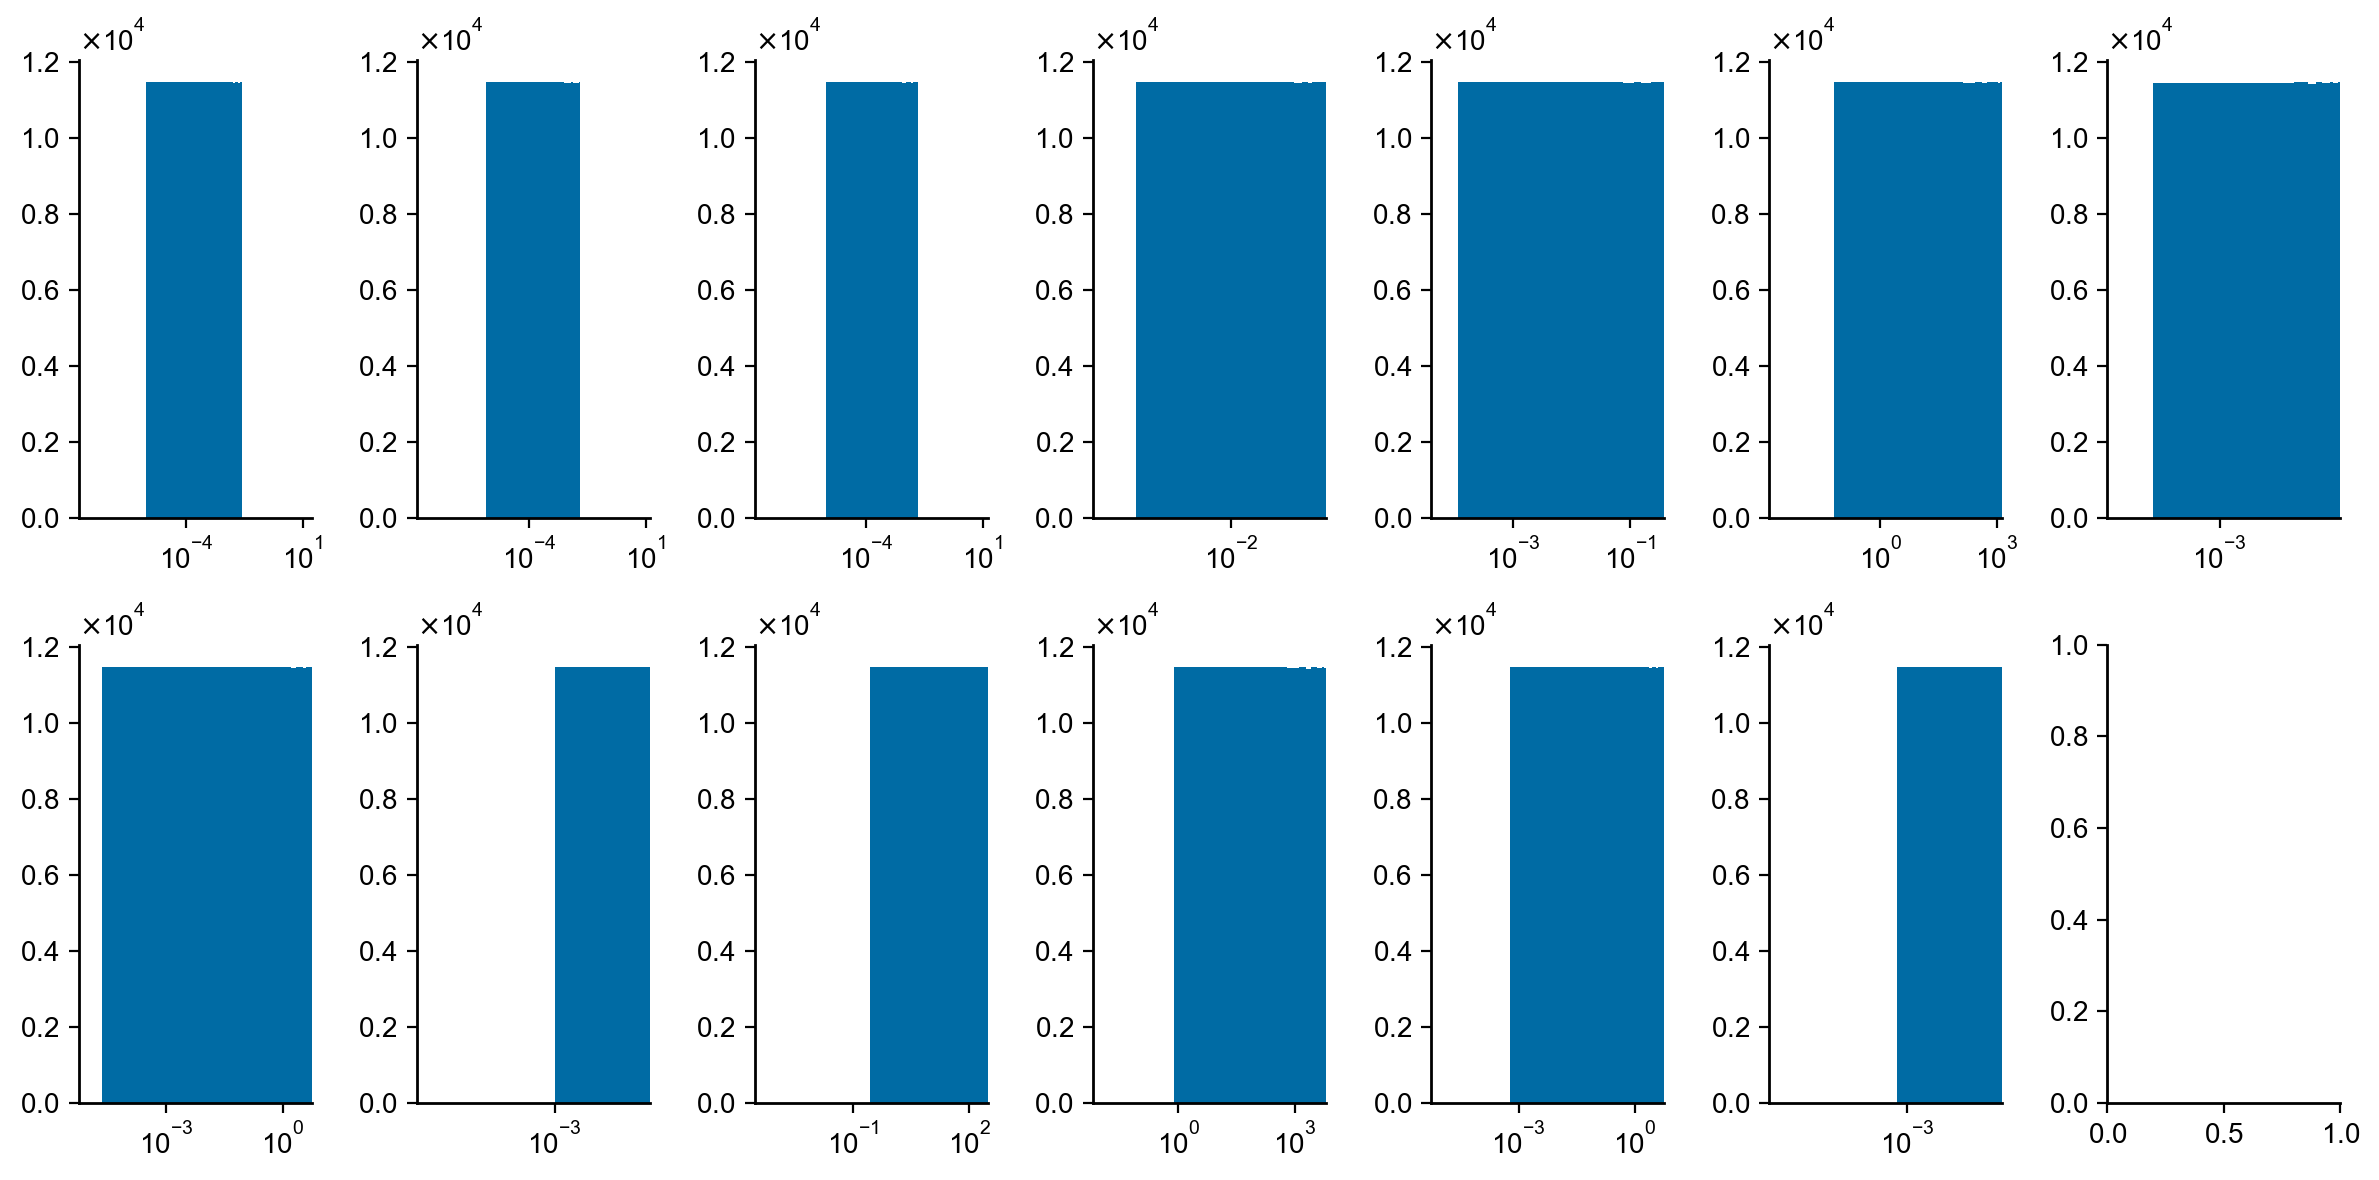

In [18]:
pnames = ['kOffAMP', 'kOffADP', 'kOffATP', 'kOffCaMKK', 'kPhosCaMKK', 'kOffLKB1', 'kPhosLKB1', 'kOffPP', 'kDephosPP', 'kOffAMPK', 'kPhosAMPK', 'kOffPP1', 'kDephosPP1']
fig, ax = plt.subplots(2,7, figsize = (12,6))
iter = 0
for i in range(4):
    for j in range(7):
        if iter < 13:
            ax[i][j].hist(MA_single_params[:,iter])
            ax[i][j].set_xscale('log')
            param = pnames[iter]
            ax[i][j].set_xlim(MA_single_info['param_bounds'][param])
            iter += 1

fig.tight_layout()

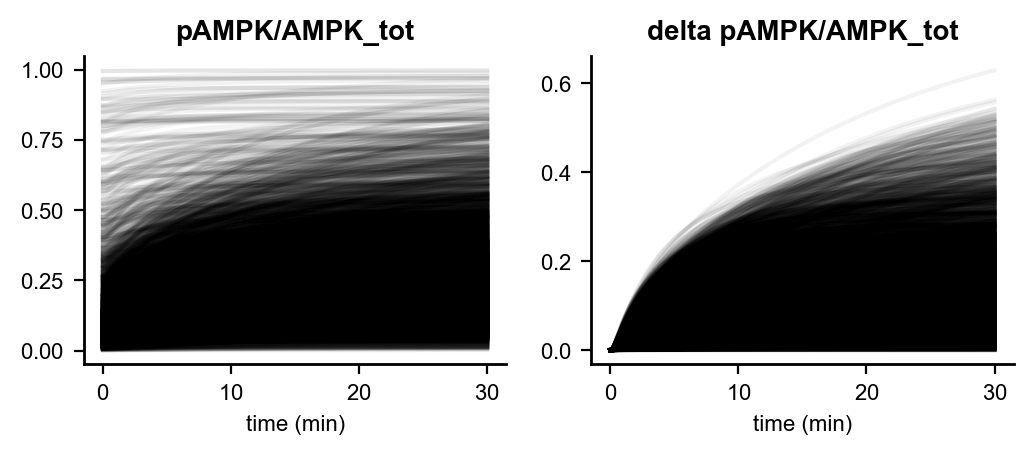

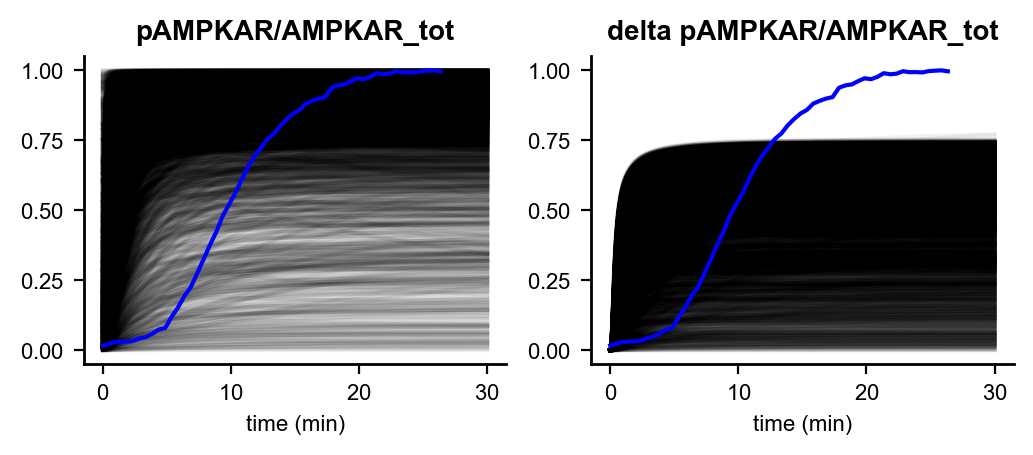

In [19]:
ampk_states = ["AMPK", "AMP_AMPK" , "ADP_AMPK" , "ATP_AMPK", "CaMKK_AMPK" , "CaMKK_AMP_AMPK" , "CaMKK_ADP_AMPK" , "CaMKK_ATP_AMPK" , "LKB1_AMP_AMPK" , "LKB1_ADP_AMPK"]
pAMPK_states = ["pAMPK", "AMP_pAMPK" , "ADP_pAMPK" , "ATP_pAMPK" , "PP_pAMPK" , "PP_ATP_pAMPK", "AMPKAR_AMP_pAMPK"]
ampkar_states = ['AMPKAR', 'AMPKAR_AMP_pAMPK']
pAMPKAR_states = MA_single_info['pampkar_states']

ampk_state_idxs = [list(MA_single_info['init_conds'].keys()).index(state) for state in ampk_states]
pAMPK_state_idxs = [list(MA_single_info['init_conds'].keys()).index(state) for state in pAMPK_states]
ampkar_state_idxs = [list(MA_single_info['init_conds'].keys()).index(state) for state in ampkar_states]
pAMPKAR_state_idxs = [list(MA_single_info['init_conds'].keys()).index(state) for state in pAMPKAR_states]

times = np.linspace(0, 1800, 1000)

random_integers = np.random.choice(114688, 5000, replace=False)
fig, ax = plt.subplots(1,2, figsize=(6, 2))
for j in random_integers:
    ax[0].plot(times/60, MA_single_stressed[j, np.array(pAMPK_state_idxs), :].sum(axis=0)/(MA_single_stressed[j, np.array(ampk_state_idxs), :].sum(axis=0)+MA_single_stressed[j, np.array(pAMPK_state_idxs), :].sum(axis=0)), color='black', alpha=0.05)
    ax[1].plot(times/60, MA_single_stressed[j, np.array(pAMPK_state_idxs), :].sum(axis=0)/(MA_single_stressed[j, np.array(ampk_state_idxs), :].sum(axis=0)+MA_single_stressed[j, np.array(pAMPK_state_idxs), :].sum(axis=0)) - MA_single_stressed[j, np.array(pAMPK_state_idxs), 0].sum(axis=0)/(MA_single_stressed[j, np.array(ampk_state_idxs), 0].sum(axis=0)+MA_single_stressed[j, np.array(pAMPK_state_idxs), 0].sum(axis=0)), color='black', alpha=0.05)
ax[0].set_title('pAMPK/AMPK_tot', fontsize=10)
ax[1].set_title('delta pAMPK/AMPK_tot', fontsize=10)
ax[0].set_xlabel('time (min)', fontsize=8)
ax[1].set_xlabel('time (min)', fontsize=8)
for tick in ax[0].get_xticklabels() + ax[0].get_yticklabels() + ax[1].get_xticklabels() + ax[1].get_yticklabels():
    tick.set_fontsize(8)

fig, ax = plt.subplots(1,2, figsize=(6, 2))
for j in random_integers:
    ax[0].plot(times/60, MA_single_stressed[j, np.array(pAMPKAR_state_idxs), :].sum(axis=0)/(MA_single_stressed[j, np.array(ampkar_state_idxs), :].sum(axis=0)+MA_single_stressed[j, np.array(pAMPKAR_state_idxs), :].sum(axis=0)), color='black', alpha=0.05)
    ax[1].plot(times/60, MA_single_stressed[j, np.array(pAMPKAR_state_idxs), :].sum(axis=0)/(MA_single_stressed[j, np.array(ampkar_state_idxs), :].sum(axis=0)+MA_single_stressed[j, np.array(pAMPKAR_state_idxs), :].sum(axis=0)) - MA_single_stressed[j, np.array(pAMPKAR_state_idxs), 0].sum(axis=0)/(MA_single_stressed[j, np.array(ampkar_state_idxs), 0].sum(axis=0)+MA_single_stressed[j, np.array(pAMPKAR_state_idxs), 0].sum(axis=0)), color='black', alpha=0.05)
ax[0].set_title('pAMPKAR/AMPKAR_tot', fontsize=10)
ax[1].set_title('delta pAMPKAR/AMPKAR_tot', fontsize=10)
ax[0].set_xlabel('time (min)', fontsize=8)
ax[1].set_xlabel('time (min)', fontsize=8)
for tick in ax[0].get_xticklabels() + ax[0].get_yticklabels() + ax[1].get_xticklabels() + ax[1].get_yticklabels():
    tick.set_fontsize(8)

ax[0].plot(cyto_times, cyto_data, 'b')
ax[1].plot(cyto_times, cyto_data, 'b')

In [29]:
ampkar_states = MA_single_info['ampkar_states']
pAMPKAR_states = MA_single_info['pampkar_states']

ampkar_state_idxs = [list(MA_single_info['init_conds'].keys()).index(state) for state in ampkar_states]
pampkar_state_idxs = [list(MA_single_info['init_conds'].keys()).index(state) for state in pAMPKAR_states]

sol_samples = MA_single_stressed[:,pampkar_state_idxs,:].sum(axis=1) # note is technically divided by ampkar, but that =1 

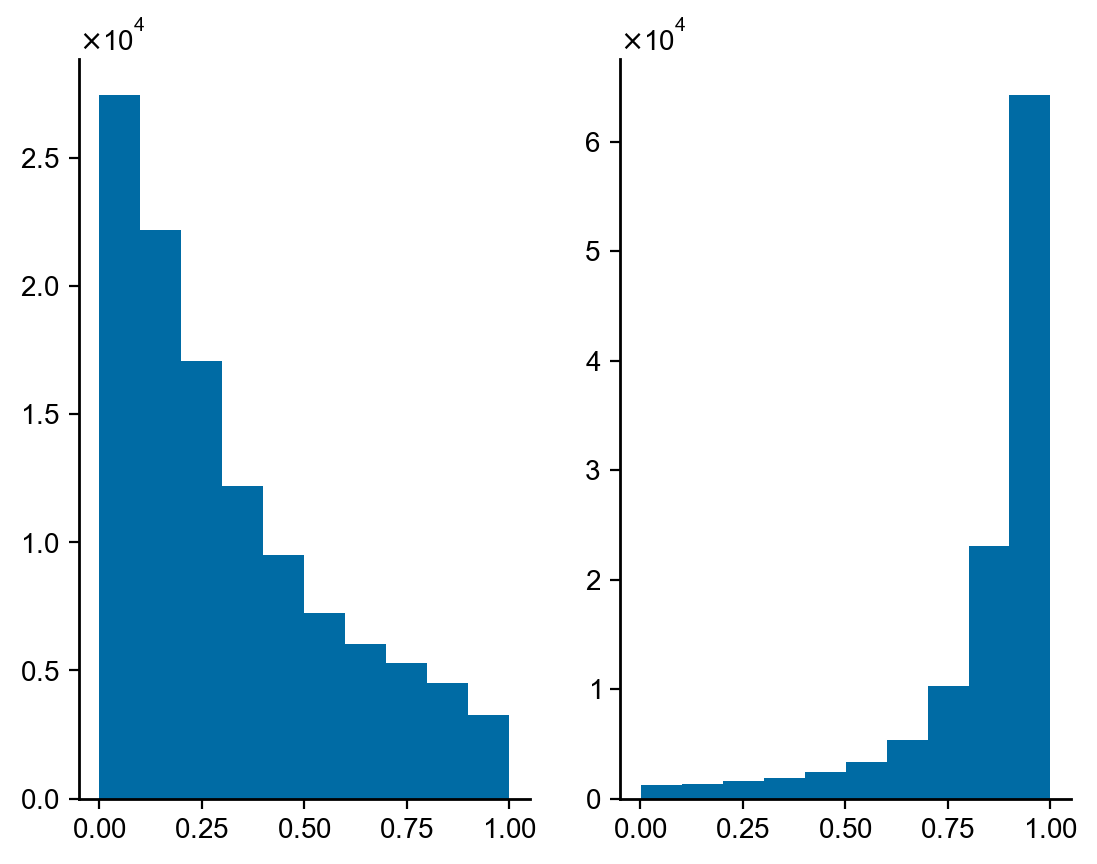

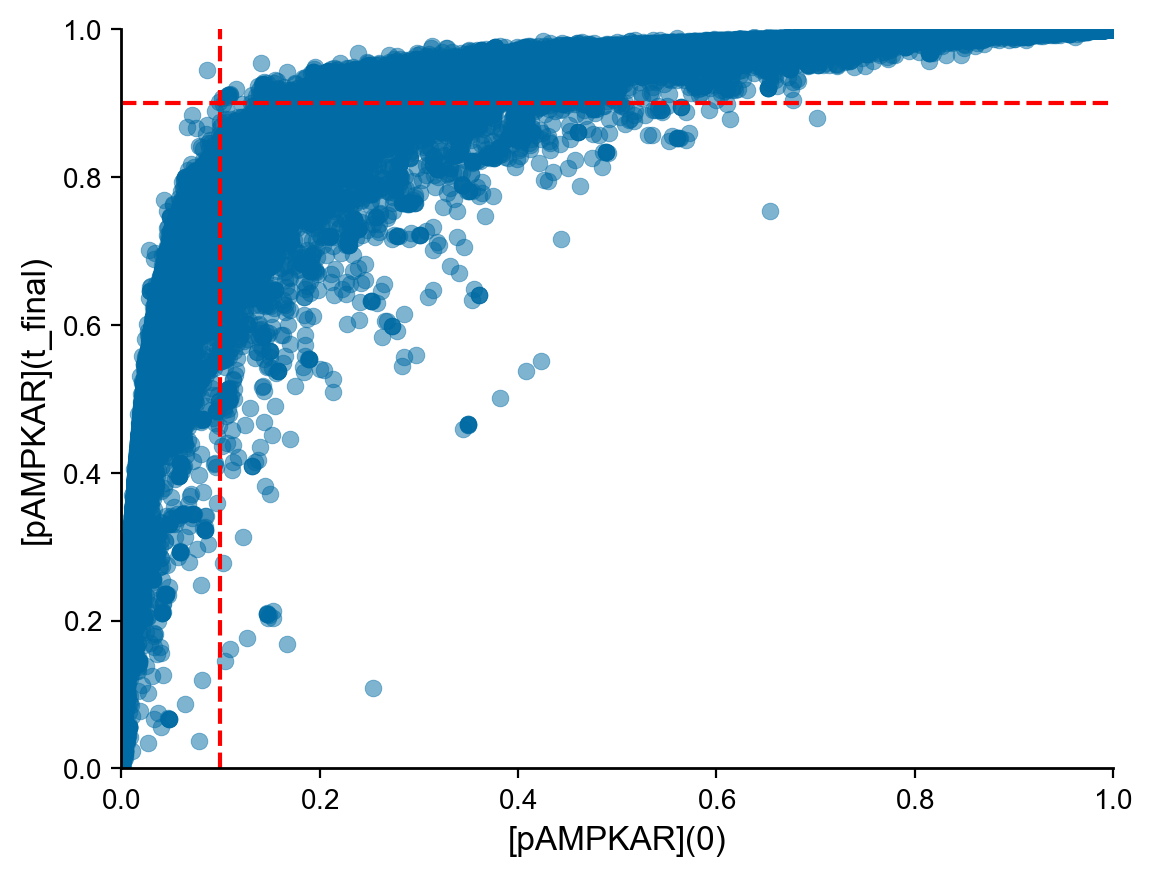

In [46]:
fig, ax = plt.subplots(1,2)
ax[0].hist(sol_samples[:,0])
ax[1].hist(sol_samples[:,-1])

fig, ax = plt.subplots()
ax.scatter(sol_samples[:,0], sol_samples[:,-1], alpha=0.5)
ax.set_xlabel('[pAMPKAR](0)')
ax.set_ylabel('[pAMPKAR](t_final)')
ax.set_xlim([0, 1])
ax.set_ylim([0,1])
ax.plot([0.1,0.1], [0,1], 'r--')
ax.plot([0,1], [0.9,0.9], 'r--')

In [45]:
np.intersect1d(np.where(sol_samples[:,0]<=0.1)[0], np.where(sol_samples[:,-1]>=0.9)[0])

array([ 1004, 46338])